
# DAT540 Group Project — Explainable Machine Learning for Gallstone Disease

**University of Stavanger (UiS) — DAT540 Data Science**

## Research question
> How accurately can routinely collected demographic, body-composition, bioimpedance, and laboratory variables distinguish patients with gallstone disease from patients without gallstones, and which variables contribute most to the model predictions?

### Project design
This notebook follows a complete data-science workflow:

1. Load and validate the dataset
2. Exploratory data analysis (EDA)
3. Leakage-safe train/test preparation
4. Train and tune multiple classification models
5. Evaluate on an untouched test set
6. Explain predictions using model-agnostic permutation importance and logistic-regression coefficients
7. Quantify uncertainty with a bootstrap confidence interval
8. Save reproducible result tables

**Important target convention:** the original UCI dataset encodes `Gallstone Status` as  
`0 = gallstones present` and `1 = gallstones absent`.

For easier interpretation of medical classification metrics, this notebook recodes the target to:

- `1 = gallstones present` (**positive class**)
- `0 = gallstones absent`

This makes recall/sensitivity refer directly to detecting patients who have gallstones.



## 1. Imports and reproducibility

Only common scientific-Python libraries are used. `random_state=42` is used consistently where applicable so the analysis is reproducible.


In [2]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

print("Imports complete.")


Imports complete.



## 2. Load the dataset

The loader checks a few sensible relative paths so the notebook works both in this supplied project structure and if the CSV is placed beside the notebook.


In [3]:

candidate_paths = [
    Path("data/dataset-uci-csv.csv"),
    Path("data/dataset-uci.csv"),
    Path("dataset-uci-csv.csv"),
    Path("dataset-uci.csv"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Place the Gallstone CSV in the 'data' folder "
        "or beside this notebook."
    )

# The UCI file uses semicolon separators and comma decimals.
data_raw = pd.read_csv(DATA_PATH, sep=";", decimal=",")
data_raw.columns = data_raw.columns.str.strip()

print(f"Loaded: {DATA_PATH}")
print(f"Dataset shape: {data_raw.shape}")
display(data_raw.head())


Loaded: dataset-uci.csv
Dataset shape: (319, 39)


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,27.1,52.9,21.2,31.7,40.0,19.2,80.84,18.88,9,3.7,71.4,23.4,17.8,10.6,39.7,0,102.0,250.0,175.0,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,30.5,43.1,19.5,23.6,45.0,32.8,67.20,16.68,15,3.2,60.3,38.8,31.0,18.4,32.7,0,94.0,172.0,108.0,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,31.2,47.2,20.1,27.1,43.0,27.3,72.67,16.35,15,3.3,62.9,41.7,24.9,16.2,34.0,0,103.0,179.0,124.0,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,24.0,41.4,17.0,24.4,41.0,15.8,84.19,16.90,6,2.9,54.1,9.0,10.7,6.5,29.2,1,69.0,173.0,73.0,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,28.3,51.4,20.0,31.4,39.0,20.0,80.02,16.81,8,3.5,68.2,28.6,17.9,10.4,37.4,2,109.0,205.0,154.0,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6



## 3. Initial data validation

We inspect:

- shape and data types
- missing values
- duplicate rows
- constant columns
- unexpected negative measurements
- raw target distribution

No row is removed merely because it is statistically extreme. In clinical data, an extreme measurement can be a legitimate patient observation. Blanket outlier deletion can also change the target distribution and produce overly optimistic evaluation. Any exclusion should therefore require a defensible data-quality reason.


In [4]:

TARGET_RAW = "Gallstone Status"

if TARGET_RAW not in data_raw.columns:
    raise KeyError(f"Expected target column '{TARGET_RAW}' was not found.")

print("Data types:")
display(data_raw.dtypes.to_frame("dtype"))

missing_total = int(data_raw.isna().sum().sum())
duplicate_rows = int(data_raw.duplicated().sum())
constant_columns = [c for c in data_raw.columns if data_raw[c].nunique(dropna=False) <= 1]

numeric_features_raw = data_raw.drop(columns=[TARGET_RAW]).select_dtypes(include=np.number)
negative_value_count = int((numeric_features_raw < 0).sum().sum())

print(f"Missing values: {missing_total}")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Constant columns: {constant_columns}")
print(f"Negative numeric feature values: {negative_value_count}")

print("\nRaw target counts (UCI coding: 0 = present, 1 = absent):")
display(data_raw[TARGET_RAW].value_counts().sort_index().rename("count").to_frame())

print("\nSummary statistics:")
display(data_raw.describe().T)


Data types:


,dtype
Gallstone Status,int64
Age,int64
Gender,int64
Comorbidity,int64
Coronary Artery Disease (CAD),int64
Hypothyroidism,int64
Hyperlipidemia,int64
Diabetes Mellitus (DM),int64
Height,int64
Weight,float64


Missing values: 0
Duplicate rows: 0
Constant columns: []
Negative numeric feature values: 0

Raw target counts (UCI coding: 0 = present, 1 = absent):


,count
Gallstone Status,
0,161
1,158



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.495298,0.500763,0.00,0.000,0.000000,1.000,1.00
Age,319.0,48.068966,12.114558,20.00,38.500,49.000000,56.000,96.00
Gender,319.0,0.492163,0.500724,0.00,0.000,0.000000,1.000,1.00
Comorbidity,319.0,0.335423,0.517340,0.00,0.000,0.000000,1.000,3.00
Coronary Artery Disease (CAD),319.0,0.037618,0.190568,0.00,0.000,0.000000,0.000,1.00
Hypothyroidism,319.0,0.028213,0.165841,0.00,0.000,0.000000,0.000,1.00
Hyperlipidemia,319.0,0.025078,0.156609,0.00,0.000,0.000000,0.000,1.00
Diabetes Mellitus (DM),319.0,0.134796,0.342042,0.00,0.000,0.000000,0.000,1.00
Height,319.0,167.156740,10.053030,145.00,159.500,168.000000,175.000,191.00
Weight,319.0,80.564890,15.709069,42.90,69.600,78.800000,91.250,143.50



## 4. Define the prediction target

The raw UCI coding is reversed relative to the usual classification convention. We create a new target where `1` is the disease-positive class.

This recoding does **not** alter the data; it only makes interpretation of recall, precision, ROC curves, and confusion matrices less error-prone.


In [5]:

data = data_raw.copy()

# UCI: 0 = gallstones present, 1 = gallstones absent.
# Recode so the medical condition is the positive class:
data["Gallstone Present"] = 1 - data[TARGET_RAW].astype(int)

X = data.drop(columns=[TARGET_RAW, "Gallstone Present"])
y = data["Gallstone Present"].astype(int)

print("Analysis target counts:")
target_counts = y.value_counts().sort_index()
target_counts.index = ["No gallstones (0)", "Gallstones present (1)"]
display(target_counts.rename("count").to_frame())

assert set(y.unique()) == {0, 1}
assert len(X) == len(y)
assert X.isna().sum().sum() == 0


Analysis target counts:


,count
No gallstones (0),158
Gallstones present (1),161



## 5. Exploratory data analysis

EDA is descriptive. It helps us understand the sample and identify useful patterns, but correlation must **not** be interpreted as causation.

We use the disease-positive target (`1 = gallstones present`) throughout the figures.


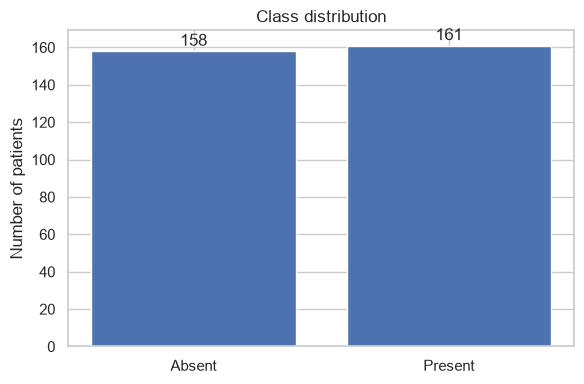

In [6]:

# Plot 1: class balance
class_counts = (
    y.map({0: "Absent", 1: "Present"})
    .value_counts()
    .reindex(["Absent", "Present"])
)

plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values)
plt.title("Class distribution")
plt.xlabel("")
plt.ylabel("Number of patients")

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        str(value),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


In [7]:

# Point-biserial correlation is equivalent to Pearson correlation when
# one variable is binary. Here it is used only as a descriptive screening tool.
corr_with_target = X.corrwith(y).sort_values(
    key=lambda s: s.abs(), ascending=False
)

corr_table = pd.DataFrame({
    "correlation_with_gallstone_presence": corr_with_target,
    "absolute_correlation": corr_with_target.abs()
})

print("Top features by absolute univariate correlation:")
display(corr_table.head(15))


Top features by absolute univariate correlation:


,correlation_with_gallstone_presence,absolute_correlation
Vitamin D,0.354873,0.354873
C-Reactive Protein (CRP),-0.281995,0.281995
Lean Mass (LM) (%),0.225749,0.225749
Total Body Fat Ratio (TBFR) (%),-0.225470,0.225470
Bone Mass (BM),0.216570,0.216570
Hemoglobin (HGB),0.196872,0.196872
Extracellular Water (ECW),0.178436,0.178436
Total Fat Content (TFC),-0.170158,0.170158
Extracellular Fluid/Total Body Water (ECF/TBW),0.169826,0.169826
Hyperlipidemia,-0.161901,0.161901


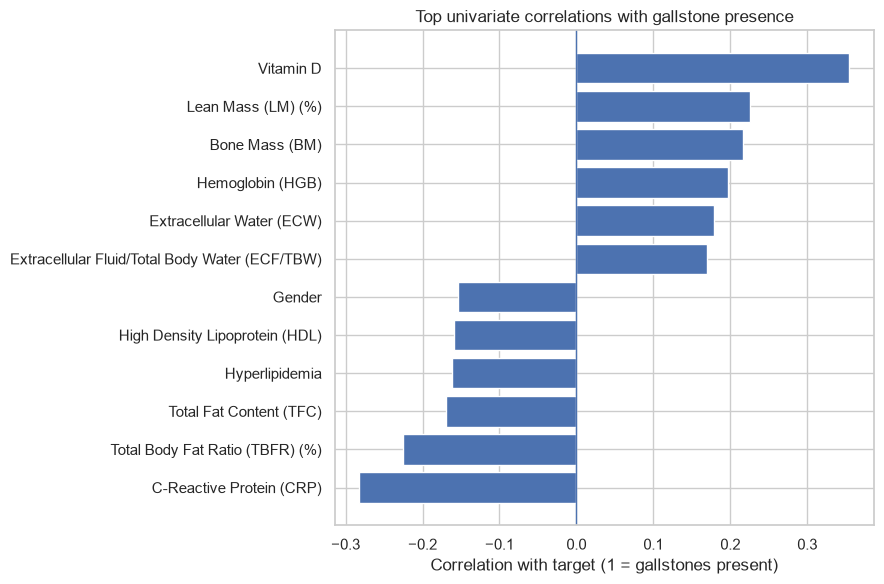

In [8]:

# Plot 2: strongest univariate correlations with disease presence
top_corr = corr_with_target.head(12).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_corr.index, top_corr.values)
plt.axvline(0, linewidth=1)
plt.title("Top univariate correlations with gallstone presence")
plt.xlabel("Correlation with target (1 = gallstones present)")
plt.ylabel("")
plt.tight_layout()
plt.show()


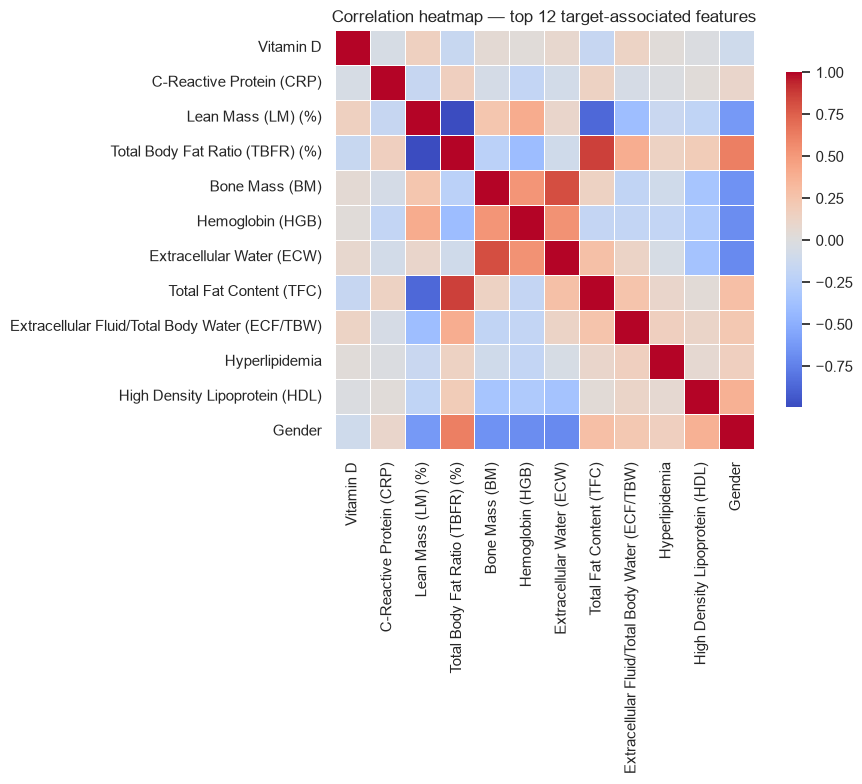

In [9]:

# Plot 3: correlation structure among the most target-associated features.
# This helps reveal potential redundancy / multicollinearity.
top_features = corr_with_target.head(12).index.tolist()
corr_matrix = X[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation heatmap — top 12 target-associated features")
plt.tight_layout()
plt.show()


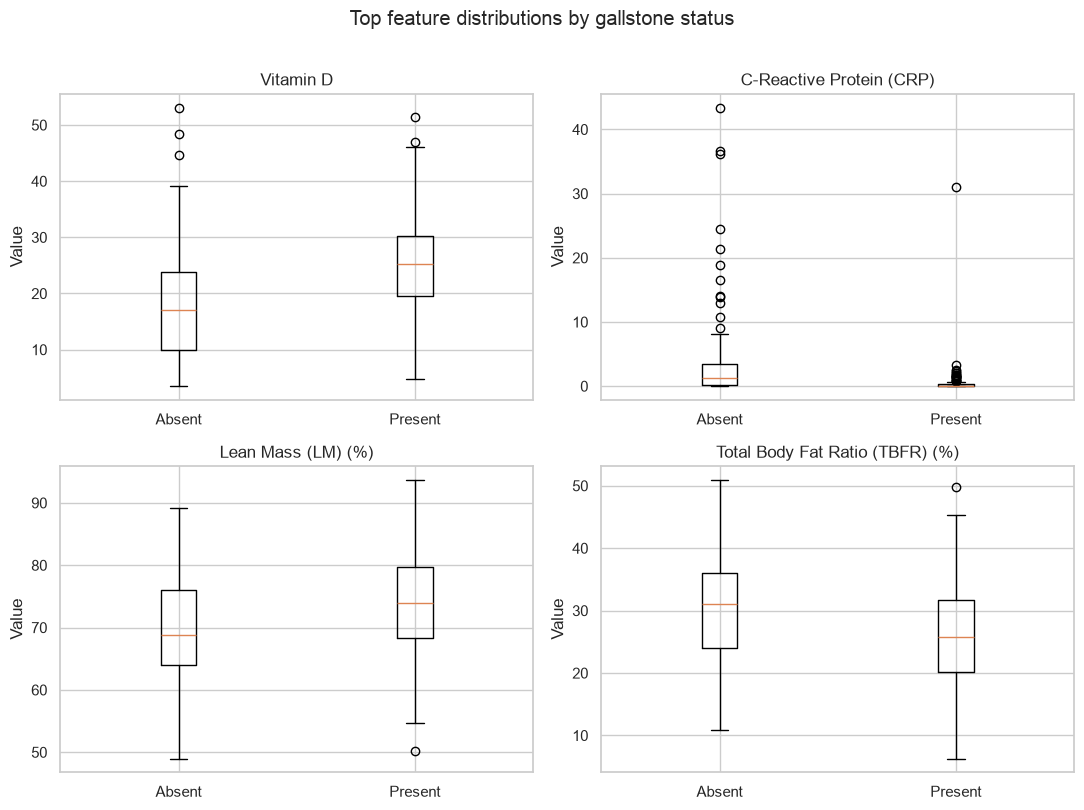

In [10]:

# Plot 4: distributions of the four strongest univariate features by diagnosis.
top4 = corr_with_target.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for ax, feature in zip(axes, top4):
    absent = data.loc[data["Gallstone Present"] == 0, feature].dropna()
    present = data.loc[data["Gallstone Present"] == 1, feature].dropna()

    ax.boxplot(
        [absent, present],
        tick_labels=["Absent", "Present"],
        showfliers=True,
    )
    ax.set_title(feature)
    ax.set_ylabel("Value")

plt.suptitle("Top feature distributions by gallstone status", y=1.01)
plt.tight_layout()
plt.show()



### EDA interpretation

The correlation ranking is useful for describing the sample, but it is **not** used to select features before cross-validation. Selecting features on the complete dataset would leak information from the test set.

For the predictive models we retain all 38 predictors because:

- the dataset has a moderate number of predictors rather than thousands,
- regularized logistic regression can shrink weak coefficients,
- tree-based models can ignore unhelpful variables through their split structure,
- removing variables solely from full-dataset correlations would introduce avoidable leakage.

Important features are instead assessed after model fitting using held-out permutation importance and logistic-regression coefficients.



## 6. Train/test split

The test set is created **before** model scaling, tuning, or model selection.

A stratified 80/20 split preserves the class proportions. The test set remains untouched during hyperparameter tuning and is used only for final evaluation.


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print("\nTraining class proportions:")
display(y_train.value_counts(normalize=True).sort_index().rename("proportion").to_frame())
print("Test class proportions:")
display(y_test.value_counts(normalize=True).sort_index().rename("proportion").to_frame())


Training samples: 255
Test samples:     64

Training class proportions:


,proportion
Gallstone Present,
0,0.494118
1,0.505882


Test class proportions:


,proportion
Gallstone Present,
0,0.5
1,0.5



## 7. Model selection and hyperparameter tuning

Four complementary classifiers are evaluated:

1. **Logistic Regression** — linear, regularized, and directly interpretable.
2. **Decision Tree** — transparent nonlinear decision rules.
3. **Random Forest** — ensemble model that captures nonlinearities and interactions while reducing single-tree variance.
4. **Gradient Boosting** — sequential tree ensemble that can model complex nonlinear relationships.

Five-fold **stratified cross-validation** is used on the training set only. Hyperparameters are selected by mean ROC-AUC.

Scaling is placed inside the Logistic Regression pipeline, ensuring that the scaler is fitted independently inside each CV fold. Tree-based methods do not require scaling.


In [12]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

model_specs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                random_state=RANDOM_STATE,
            )),
        ]),
        "grid": {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs"],
        },
    },

    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]),
        "grid": {
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__min_samples_split": [2, 5],
        },
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        "grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 5, 8],
            "model__min_samples_leaf": [1, 3],
            "model__max_features": ["sqrt"],
        },
    },

    "Gradient Boosting": {
        "pipeline": Pipeline([
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
        "grid": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.03, 0.1],
            "model__max_depth": [1, 2],
        },
    },
}

searches = {}

for name, spec in model_specs.items():
    print(f"\nTuning {name} ...")

    search = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["grid"],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )

    search.fit(X_train, y_train)
    searches[name] = search

    print(f"Best CV ROC-AUC: {search.best_score_:.3f}")
    print(f"Best parameters: {search.best_params_}")



Tuning Logistic Regression ...
Best CV ROC-AUC: 0.841
Best parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Tuning Decision Tree ...
Best CV ROC-AUC: 0.770
Best parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}

Tuning Random Forest ...
Best CV ROC-AUC: 0.843
Best parameters: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

Tuning Gradient Boosting ...
Best CV ROC-AUC: 0.836
Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100}



## 8. Final evaluation on the untouched test set

Because gallstone detection is a medical binary-classification task, one metric is not enough.

Reported metrics:

- **Accuracy:** fraction of all predictions that are correct
- **Balanced accuracy:** average of sensitivity and specificity
- **Precision:** among predicted gallstone cases, how many truly have gallstones
- **Recall / sensitivity:** among true gallstone cases, how many are detected
- **Specificity:** among patients without gallstones, how many are correctly identified
- **F1:** harmonic mean of precision and recall
- **ROC-AUC:** ranking/discrimination across all classification thresholds
- **PR-AUC:** precision-recall performance, especially useful when focusing on the positive class

The **primary model is selected using CV ROC-AUC on the training set**, not test performance. This prevents using the test set for model selection.


In [13]:

def evaluate_classifier(name, fitted_search, X_eval, y_eval):
    model = fitted_search.best_estimator_
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()
    specificity = tn / (tn + fp)

    return {
        "Model": name,
        "CV ROC-AUC": fitted_search.best_score_,
        "Test ROC-AUC": roc_auc_score(y_eval, y_prob),
        "Test PR-AUC": average_precision_score(y_eval, y_prob),
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall / Sensitivity": recall_score(y_eval, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_eval, y_pred, zero_division=0),
    }

results = pd.DataFrame([
    evaluate_classifier(name, search, X_test, y_test)
    for name, search in searches.items()
])

results = results.sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)

display(
    results.style.format({
        c: "{:.3f}" for c in results.columns if c != "Model"
    })
)

# Select the primary model using TRAINING cross-validation only.
primary_name = max(searches, key=lambda n: searches[n].best_score_)
primary_search = searches[primary_name]
primary_model = primary_search.best_estimator_

print(f"\nPrimary model chosen by CV ROC-AUC: {primary_name}")
print(f"Best training CV ROC-AUC: {primary_search.best_score_:.3f}")
print(f"Best parameters: {primary_search.best_params_}")


,Model,CV ROC-AUC,Test ROC-AUC,Test PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall / Sensitivity,Specificity,F1
0,Random Forest,0.843,0.800,0.824,0.688,0.688,0.676,0.719,0.656,0.697
1,Logistic Regression,0.841,0.886,0.891,0.781,0.781,0.725,0.906,0.656,0.806
2,Gradient Boosting,0.836,0.823,0.791,0.734,0.734,0.703,0.812,0.656,0.754
3,Decision Tree,0.770,0.739,0.683,0.672,0.672,0.622,0.875,0.469,0.727



Primary model chosen by CV ROC-AUC: Random Forest
Best training CV ROC-AUC: 0.843
Best parameters: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


In [14]:

# Detailed classification report for the preselected primary model.
primary_pred = primary_model.predict(X_test)

print(f"Classification report — {primary_name}")
print(
    classification_report(
        y_test,
        primary_pred,
        target_names=["No gallstones", "Gallstones present"],
        digits=3,
    )
)


Classification report — Random Forest
                    precision    recall  f1-score   support

     No gallstones      0.700     0.656     0.677        32
Gallstones present      0.676     0.719     0.697        32

          accuracy                          0.688        64
         macro avg      0.688     0.688     0.687        64
      weighted avg      0.688     0.688     0.687        64



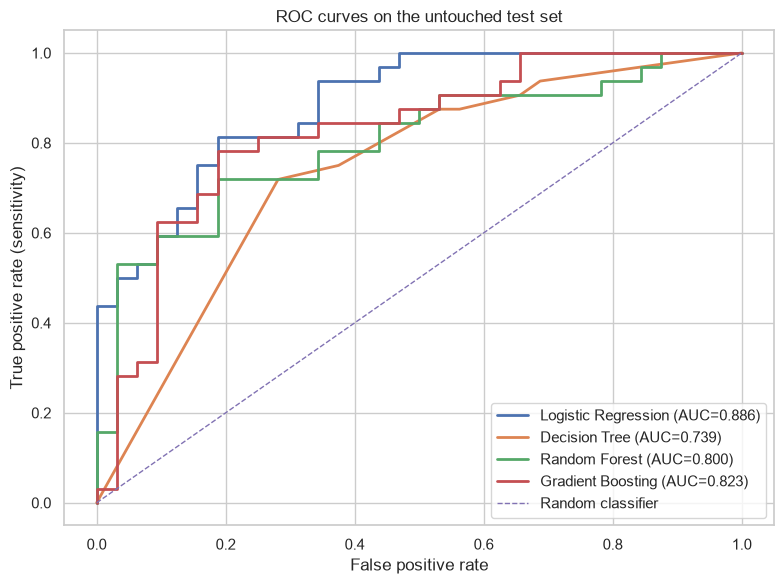

In [15]:

# Plot 5: ROC curves for all tuned models.
plt.figure(figsize=(8, 6))

for name, search in searches.items():
    probs = search.best_estimator_.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_value = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random classifier")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (sensitivity)")
plt.title("ROC curves on the untouched test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


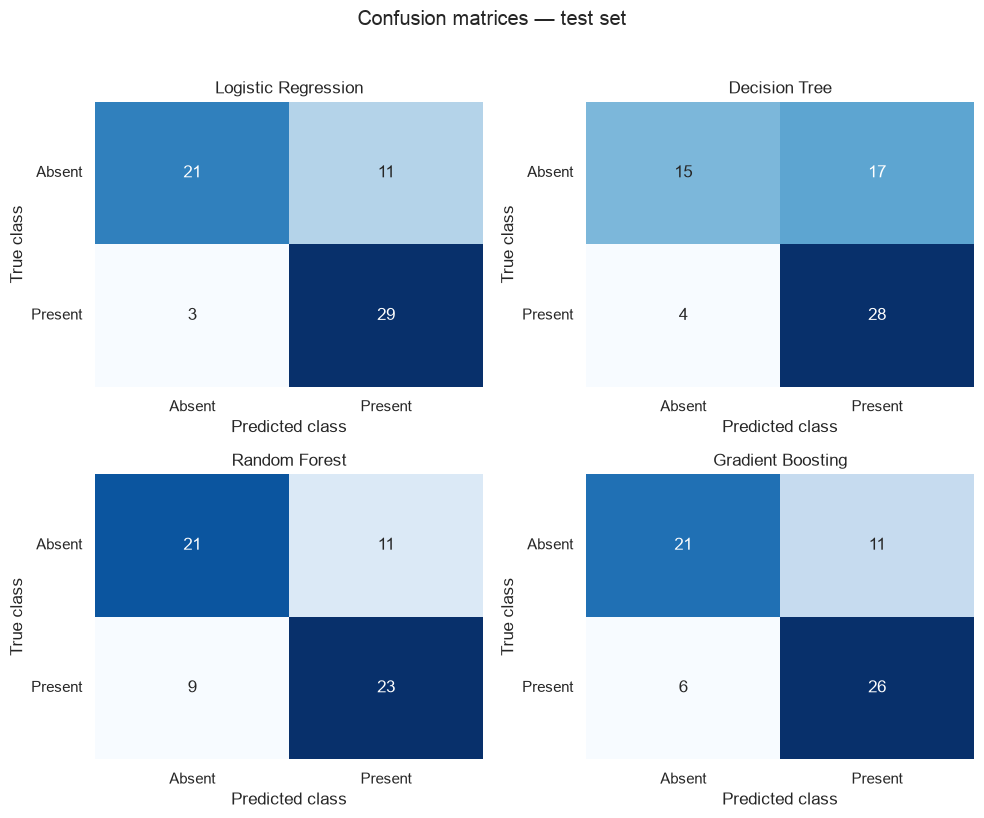

In [16]:

# Plot 6: confusion matrices for all models.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, search) in zip(axes, searches.items()):
    pred = search.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticklabels(["Absent", "Present"])
    ax.set_yticklabels(["Absent", "Present"], rotation=0)

plt.suptitle("Confusion matrices — test set", y=1.02)
plt.tight_layout()
plt.show()


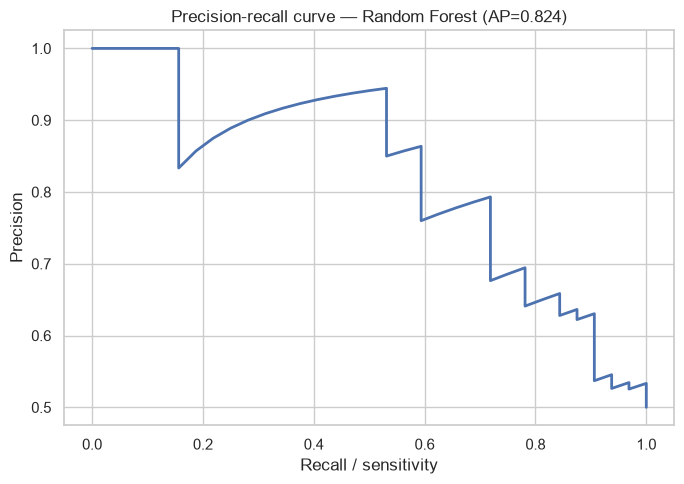

In [17]:

# Plot 7: precision-recall curve for the primary model.
primary_prob = primary_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, primary_prob)
primary_pr_auc = average_precision_score(y_test, primary_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall / sensitivity")
plt.ylabel("Precision")
plt.title(f"Precision-recall curve — {primary_name} (AP={primary_pr_auc:.3f})")
plt.tight_layout()
plt.show()



## 9. Explainability

Predictive performance answers **how well** a model discriminates patients. Explainability addresses **which variables the model relies on**.

We use two complementary approaches:

1. **Permutation importance** on the untouched test set for the primary model. Each feature is shuffled in turn; a larger drop in ROC-AUC means the model relied more strongly on that feature. This method is model-agnostic.
2. **Standardized Logistic Regression coefficients**. Positive coefficients are associated with higher predicted probability of gallstones; negative coefficients are associated with lower predicted probability, conditional on the other variables in the model.

Neither method establishes a causal medical relationship. Correlated predictors can also share or redistribute apparent importance.


Permutation importance — Random Forest


,Feature,Mean AUC decrease,Importance SD
35,C-Reactive Protein (CRP),0.124609,0.042906
37,Vitamin D,0.030371,0.014712
13,Extracellular Fluid/Total Body Water (ECF/TBW),0.023730,0.009053
18,Bone Mass (BM),0.006738,0.006889
11,Extracellular Water (ECW),0.006087,0.008388
23,Visceral Muscle Area (VMA) (Kg),0.005013,0.004071
20,Obesity (%),0.004427,0.008631
32,Alkaline Phosphatase (ALP),0.001237,0.006009
12,Intracellular Water (ICW),0.001204,0.003304
34,Glomerular Filtration Rate (GFR),0.000814,0.003558


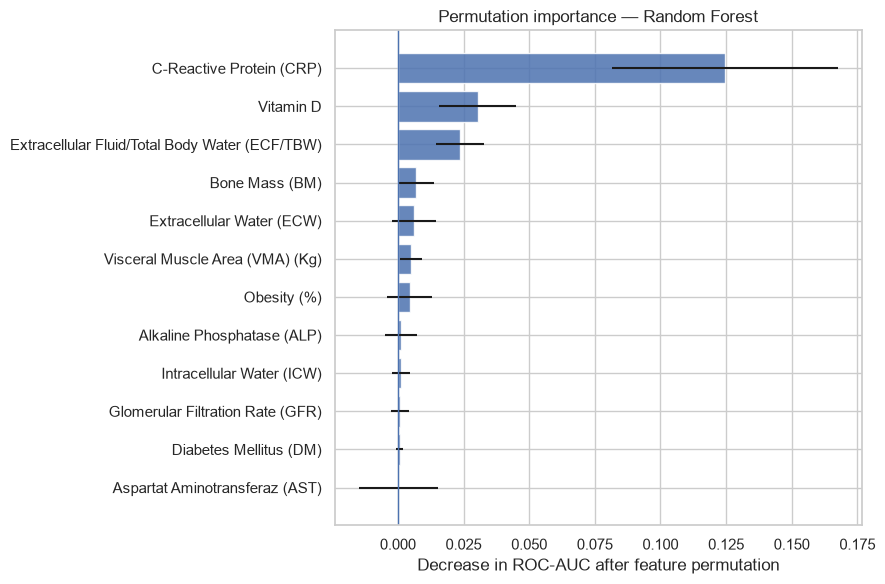

In [18]:

# Model-agnostic global importance for the primary model.
perm = permutation_importance(
    primary_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean AUC decrease": perm.importances_mean,
    "Importance SD": perm.importances_std,
}).sort_values("Mean AUC decrease", ascending=False)

print(f"Permutation importance — {primary_name}")
display(permutation_df.head(15))

top_perm = permutation_df.head(12).sort_values("Mean AUC decrease")

plt.figure(figsize=(9, 6))
plt.barh(
    top_perm["Feature"],
    top_perm["Mean AUC decrease"],
    xerr=top_perm["Importance SD"],
    alpha=0.85,
)
plt.axvline(0, linewidth=1)
plt.xlabel("Decrease in ROC-AUC after feature permutation")
plt.ylabel("")
plt.title(f"Permutation importance — {primary_name}")
plt.tight_layout()
plt.show()


,Feature,Standardized coefficient,Absolute coefficient
35,C-Reactive Protein (CRP),-1.289620,1.289620
18,Bone Mass (BM),1.179973,1.179973
12,Intracellular Water (ICW),-1.066930,1.066930
1,Gender,0.918138,0.918138
14,Total Body Fat Ratio (TBFR) (%),-0.900912,0.900912
5,Hyperlipidemia,-0.849244,0.849244
6,Diabetes Mellitus (DM),-0.835927,0.835927
37,Vitamin D,0.817221,0.817221
13,Extracellular Fluid/Total Body Water (ECF/TBW),0.790067,0.790067
30,Aspartat Aminotransferaz (AST),0.766211,0.766211


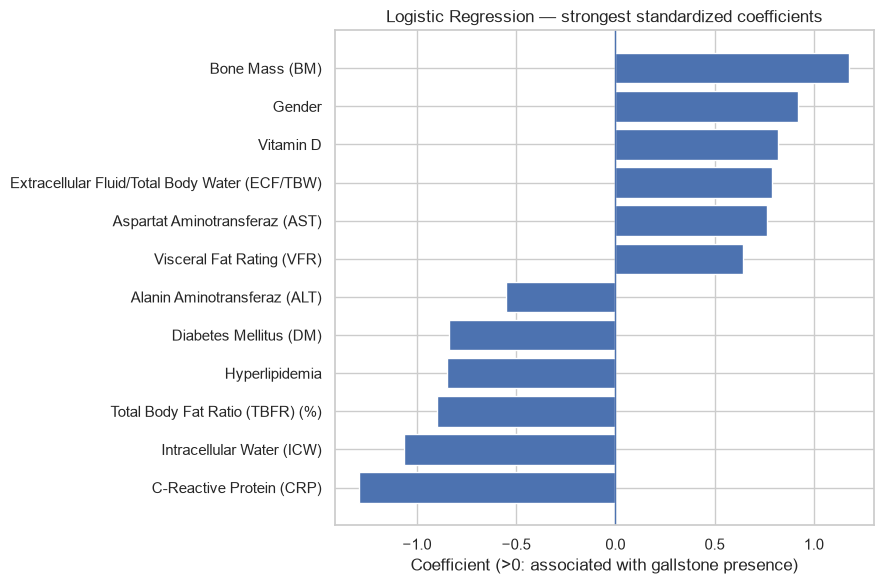

In [19]:

# Directional explanation from Logistic Regression.
lr_search = searches["Logistic Regression"]
lr_pipeline = lr_search.best_estimator_
lr_model = lr_pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Standardized coefficient": lr_model.coef_[0],
})
coef_df["Absolute coefficient"] = coef_df["Standardized coefficient"].abs()
coef_df = coef_df.sort_values("Absolute coefficient", ascending=False)

display(coef_df.head(15))

top_coef = coef_df.head(12).sort_values("Standardized coefficient")

plt.figure(figsize=(9, 6))
plt.barh(
    top_coef["Feature"],
    top_coef["Standardized coefficient"],
)
plt.axvline(0, linewidth=1)
plt.title("Logistic Regression — strongest standardized coefficients")
plt.xlabel("Coefficient (>0: associated with gallstone presence)")
plt.ylabel("")
plt.tight_layout()
plt.show()



### Interpreting importance carefully

- A high permutation importance means the fitted model loses discrimination when that variable is disrupted.
- A positive logistic coefficient means larger values are associated with a higher fitted probability of gallstones after accounting for the other predictors.
- A negative coefficient means the opposite.
- Magnitude can be affected by multicollinearity.
- These are **predictive associations**, not evidence that changing a variable would change disease risk.



## 10. Uncertainty in test ROC-AUC

The dataset is small, and the 20% test split contains only a limited number of patients. A single test ROC-AUC should therefore not be treated as exact.

We use non-parametric bootstrap resampling of the test set to obtain an approximate 95% confidence interval for the primary model's ROC-AUC.


In [20]:

rng = np.random.default_rng(RANDOM_STATE)
n_boot = 2000
boot_aucs = []

y_test_np = y_test.to_numpy()
primary_prob_np = primary_prob

for _ in range(n_boot):
    idx = rng.integers(0, len(y_test_np), len(y_test_np))
    y_b = y_test_np[idx]

    # ROC-AUC is undefined if a bootstrap sample contains one class only.
    if len(np.unique(y_b)) < 2:
        continue

    boot_aucs.append(roc_auc_score(y_b, primary_prob_np[idx]))

ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
point_auc = roc_auc_score(y_test, primary_prob)

print(f"{primary_name} test ROC-AUC: {point_auc:.3f}")
print(f"Approx. bootstrap 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Valid bootstrap samples: {len(boot_aucs)}")


Random Forest test ROC-AUC: 0.800
Approx. bootstrap 95% CI: [0.683, 0.902]
Valid bootstrap samples: 2000



## 11. Example predictions from unseen test observations

These examples demonstrate the model's output without using the test labels during training. Probabilities should be interpreted as model scores for this dataset, **not** as clinically validated patient risk estimates.


In [21]:

example = X_test.iloc[:10].copy()
example_prob = primary_model.predict_proba(example)[:, 1]
example_pred = (example_prob >= 0.5).astype(int)

prediction_examples = pd.DataFrame({
    "True class": y_test.iloc[:10].to_numpy(),
    "Predicted class": example_pred,
    "Predicted probability of gallstones": example_prob,
}, index=example.index)

display(prediction_examples.style.format({
    "Predicted probability of gallstones": "{:.3f}"
}))


,True class,Predicted class,Predicted probability of gallstones
26,1,1,0.714
58,1,1,0.812
163,0,1,0.547
215,0,1,0.625
175,0,0,0.432
263,0,0,0.269
51,1,1,0.913
100,1,1,0.735
11,1,1,0.792
107,1,1,0.607



## 12. Save result tables

The notebook saves compact result tables to `outputs/` for use when writing the report and preparing the oral presentation.


In [22]:

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)
permutation_df.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)
coef_df.to_csv(OUTPUT_DIR / "logistic_coefficients.csv", index=False)
prediction_examples.to_csv(OUTPUT_DIR / "example_predictions.csv", index=True)

print(f"Saved results to: {OUTPUT_DIR.resolve()}")


Saved results to: /Users/magnus/Desktop/DAT540/outputs



## 13. Conclusions and limitations

After running the notebook, the final report should state the numerical results produced above rather than hard-code values in advance.

### What this analysis can support
- Comparison of several supervised classifiers under the same train/test design
- An estimate of out-of-sample discrimination on an untouched test set
- Identification of variables the fitted models rely on most strongly
- Directional interpretation from regularized Logistic Regression

### Important limitations
1. **Small single-centre cohort:** only 319 patients from one hospital cohort are available.
2. **Internal validation only:** a random split from the same cohort is not equivalent to validation in another hospital or population.
3. **Statistical uncertainty:** the held-out test set is small, so performance estimates can vary materially with the sampled patients.
4. **Association, not causation:** feature importance and regression coefficients do not demonstrate causal risk factors.
5. **Correlated clinical/body-composition variables:** correlated predictors can make individual importance values unstable.
6. **No clinical deployment claim:** the model has not undergone external validation, calibration assessment across populations, prospective testing, or clinical impact evaluation.

### Recommended future work
- External validation on an independent patient cohort
- Repeated or nested cross-validation for more stable model-comparison estimates
- Probability calibration if clinically meaningful risk probabilities are required
- More extensive explainability analyses on a larger external dataset
- Prospective evaluation before considering clinical use



## References

- Esen, I., Arslan, H., Aktürk Esen, S., Gülşen, M., Kültekin, N., & Özdemir, O. (2024). *Early prediction of gallstone disease with a machine learning-based method from bioimpedance and laboratory data*. **Medicine**. DOI: 10.1097/MD.0000000000037258.
- UCI Machine Learning Repository. *Gallstone* dataset (ID 1150): https://archive.ics.uci.edu/dataset/1150/gallstone-1
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
